In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # 日本語表示に対応
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import datetime
import pymysql
import numpy as np
import python_ss.python_ss as ps
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import json

import os
import ast
import db_dtypes
from google.cloud import bigquery
from google.oauth2 import service_account
from google.cloud import secretmanager
from google.oauth2.credentials import Credentials
from googleapiclient.discovery import build
from google_auth_oauthlib.flow import InstalledAppFlow
# importでエラーが出てしまった場合は、コマンドプロンプトにて「pip install ”必要なモジュール”」でインストールしていただく必要がございます。
# 例. pip install db_dtypes

import xlsxwriter

from decimal import Decimal
import calendar
# import utils
# from utils import *
#importlib.reload(utils)
print(os.getcwd())

# ★★★ 日本語の文字化けを解消するためのおまじない ★★★
japanize_matplotlib.japanize()


z:\Users\suehara\Documents\python\analysis


In [31]:
def access_secret_version(project_id, secret_id, version_id='latest'):
    client = secretmanager.SecretManagerServiceClient()

    name = f"projects/{project_id}/secrets/{secret_id}/versions/{version_id}"
    response = client.access_secret_version(request={"name": name})
    payload = response.payload.data.decode("UTF-8")
    return ast.literal_eval(payload)

# 上記関数を実行するコードが記載されています。こちらもそのままお使いください。
credentials = service_account.Credentials.from_service_account_info(
  access_secret_version('temp-for-sandbox', 'TEMP_CREDENTIAL_KEY'),
  scopes=["https://www.googleapis.com/auth/cloud-platform"],
)

z:\Users\suehara\Documents\python\analysis\.venv\Lib\site-packages\google\auth\_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [32]:
# --- 1. データの読み込みと前処理 ---
print("--- 1. データの読み込みと前処理 ---")

SCOPES = ['https://www.googleapis.com/auth/spreadsheets.readonly',
          'https://www.googleapis.com/auth/spreadsheets']
json_path = r"Z:\Users\suehara\Documents\python\analysis\python_ss\credentials.json"
service = ps.get_auth(SCOPES,json_path)
SPREADSHEET_ID = '1d2mYjQ2R51AD6B3UXnHRnaeZ25B4vrOoAmA2psmsQME'
Sheet_NAME = 'raw_data!'
Sheet_row = "A3:AI"
RANGE_NAME = Sheet_NAME+Sheet_row
df = ps.get_ss(SPREADSHEET_ID,RANGE_NAME,service)

# 日付形式の列をdatetime型に変換
date_columns = ['shoki_setteibi', 'shoki_jisshibi', 'hon_setteibi', 'hon_yoteibi', 'hon_jisshibi', 'seiyakubi']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 予測のターゲットとなる「成約フラグ」を作成 (成約日があれば1, なければ0)
df['seiyaku_flag'] = df['seiyakubi'].notna().astype(int)

# モデルで使用する列を数値型に変換します。
numeric_cols = [
    'uriage', 'jisshibi_sa', 'hon_seq', 'shoki_seq', 'sai_flg',
    'annual_income', 'seiyaku_lead_time', 'kijun_nenshu', 'houshuuritsu', 'seiko_hoshu'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- 新しい特徴量の追加 ---
print("\n--- ★ 新しい特徴量（first_yomi, yomi_final）の追加 ---")
# ヨミの序列を定義
yomi_map = {
    'A': 6, 'B': 5, 'C': 4, 'D+': 3, 'D': 2, 'D-': 1,
    'オチ（企）': 0, 'オチ（候）': 0, 'オチ（双）': 0
}

# ヨミを数値に変換
df['first_yomi_numeric'] = df['first_yomi'].map(yomi_map)
df['yomi_final_numeric'] = df['yomi_final'].map(yomi_map)

# ヨミの変化を計算（final - first）
# 欠損値がある場合は0で埋める
df['yomi_change'] = (df['yomi_final_numeric'] - df['first_yomi_numeric']).fillna(0)
print("ヨミ関連の特徴量を作成しました。")


print("データ読み込み完了")

--- 1. データの読み込みと前処理 ---

--- ★ 新しい特徴量（first_yomi, yomi_final）の追加 ---
ヨミ関連の特徴量を作成しました。
データ読み込み完了



--- 2. データの可視化 ---


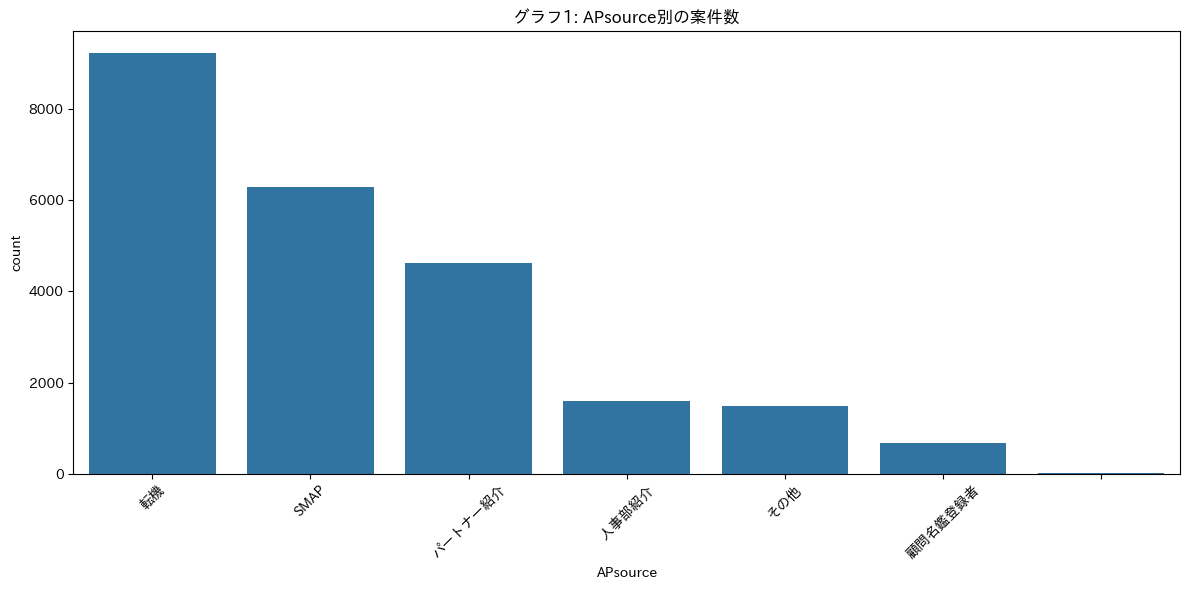

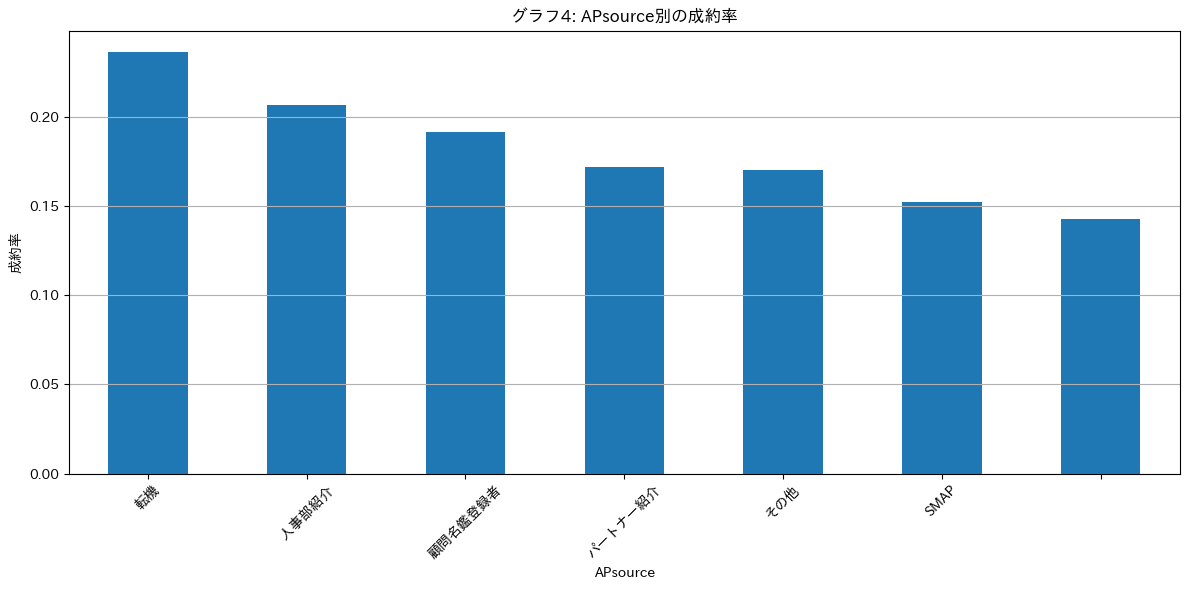

可視化完了


In [33]:
# --- 2. データの可視化（前回と同じ内容） ---
# このセクションは前回と同じですが、日本語が正しく表示されるようになっています
print("\n--- 2. データの可視化 ---")

# ① APsource別の案件数
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='APsource', order=df['APsource'].value_counts().index)
plt.title('グラフ1: APsource別の案件数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ② APsource別の成約率
apsource_seiyaku_rate = df.groupby('APsource')['seiyaku_flag'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
apsource_seiyaku_rate.plot(kind='bar')
plt.title('グラフ4: APsource別の成約率')
plt.ylabel('成約率')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("可視化完了")


In [34]:
# --- 3. 業績予測モデルの構築 ---
print("\n--- 3. 業績予測モデルの構築 ---")

# ★★★ 予測したい期間を設定 ★★★
PREDICTION_START_DATE = pd.to_datetime('2025-06-26')
PREDICTION_END_DATE = pd.to_datetime('2025-09-30')
# ★★★ 成約と判断する確率のしきい値 ★★★
PROBABILITY_THRESHOLD = 0.5 # 50%以上の確率で成約すると予測されたものを対象とする

print(f"予測対象期間: {PREDICTION_START_DATE.date()} から {PREDICTION_END_DATE.date()} まで")

# 3-1a. リードタイムの計算
print("\n--- 3-1a. 平均リードタイムの計算 ---")
df_train_source = df[df['seiyakubi'].notna()]
avg_lead_time = df_train_source.groupby('APsource')['seiyaku_lead_time'].mean().to_dict()
overall_avg_lead_time = df_train_source['seiyaku_lead_time'].mean()
print("平均リードタイムの計算完了")

# 3-1b. モデルが学習しやすいようにデータを加工（特徴量エンジニアリング）
print("\n--- 3-1b. 特徴量エンジニアリング ---")
features = [
    'uriage', 'jisshibi_sa', 'hon_seq', 'shoki_seq', 'APsource',
    'kumite', 'kohosha_tanto', 'kigyo_tanto', 'yakushoku_class',
    'first_mendan_tanto', 'sai_flg',
    'first_yomi_numeric', 'yomi_final_numeric', 'yomi_change' # ヨミ関連の3つの特徴量を追加
]

df_model = pd.get_dummies(df, columns=['APsource', 'kumite', 'yakushoku_class', 'kohosha_tanto', 'kigyo_tanto', 'first_mendan_tanto'], dummy_na=True)

encoded_features = []
for feature in features:
    cols = [col for col in df_model.columns if col.startswith(feature)]
    if len(cols) > 0:
        encoded_features.extend(cols)
    else:
        encoded_features.append(feature)

df_model[encoded_features] = df_model[encoded_features].fillna(0)
print("特徴量の準備完了")


# 3-2. データを「学習用」「テスト用」に分割
print("\n--- 3-2. 学習用・テスト用データへの分割 ---")
X = df_model[encoded_features]
y = df_model['seiyaku_flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"全データ数: {len(df_model)}件")
print(f"学習データ数: {len(X_train)}件 (成約: {y_train.sum()}件)")
print(f"テストデータ数: {len(X_test)}件 (成約: {y_test.sum()}件)")

# 3-3. LightGBMモデルで「成約するかどうか」を学習
print("\n--- 3-3. モデルの学習 ---")
model = lgb.LGBMClassifier(random_state=42)
model.fit(X_train, y_train)
print("モデルの学習完了")

# 3-4. モデルの性能を評価
print("\n--- 3-4. モデル性能の評価 ---")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"モデルの正解率 (Accuracy): {accuracy:.4f}")
print("\n▼ 混同行列 (Confusion Matrix):")
cm = confusion_matrix(y_test, y_pred)
print(cm)


--- 3. 業績予測モデルの構築 ---
予測対象期間: 2025-06-26 から 2025-09-30 まで

--- 3-1a. 平均リードタイムの計算 ---
平均リードタイムの計算完了

--- 3-1b. 特徴量エンジニアリング ---
特徴量の準備完了

--- 3-2. 学習用・テスト用データへの分割 ---
全データ数: 23915件
学習データ数: 19132件 (成約: 3721件)
テストデータ数: 4783件 (成約: 930件)

--- 3-3. モデルの学習 ---
[LightGBM] [Info] Number of positive: 3721, number of negative: 15411
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001862 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 19132, number of used features: 509
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.194491 -> initscore=-1.421089
[LightGBM] [Info] Start training from score -1.421089
モデルの学習完了

--- 3-4. モデル性能の評価 ---
モデルの正解率 (Accuracy): 0.9716

▼ 混同行列 (Confusion Matrix):
[[3838   15]
 [ 121  809]]


In [35]:
# --- 4. 未来の業績を予測 ---
print("\n--- 4. 未来の業績を予測 ---")

# 4-1. 予測対象となる「現在未成約」の案件データを準備
df_predict = df_model[df_model['seiyakubi'].isna()].copy()
X_to_predict = df_predict[encoded_features]
print(f"予測対象の未成約案件数: {len(X_to_predict)}件")

# 4-2. 未成約案件の「成約確率」を予測
print("\n--- 4-2. 成約確率の予測 ---")
probabilities = model.predict_proba(X_to_predict)[:, 1]
df_predict['seiyaku_probability'] = probabilities
print("成約確率の予測完了")

# 4-3. 平均リードタイムを使い、「予測成約日」を推定
print("\n--- 4-3. 予測成約日の推定 ---")
df_predict['predicted_lead_time'] = df.loc[df_predict.index, 'APsource'].map(avg_lead_time).fillna(overall_avg_lead_time)
df_predict['predicted_seiyaku_date'] = df_predict['hon_jisshibi'] + pd.to_timedelta(df_predict['predicted_lead_time'], unit='D')
print("予測成約日の推定完了")


--- 4. 未来の業績を予測 ---
予測対象の未成約案件数: 19264件

--- 4-2. 成約確率の予測 ---
成約確率の予測完了

--- 4-3. 予測成約日の推定 ---
予測成約日の推定完了



--- 5. 予測結果の分析（デバッグ用） ---

▼ 予測結果（フィルター前）のサマリー:
       seiyaku_probability         predicted_seiyaku_date
count         19264.000000                          16393
mean              0.024188  2021-07-10 03:59:15.390174976
min               0.000245            2015-03-23 00:00:00
50%               0.009486  2021-07-16 07:37:20.816326656
75%               0.022604  2023-11-04 07:37:20.816326656
90%               0.052531  2024-10-08 22:28:17.071129600
95%               0.102239  2025-01-09 09:41:32.307692288
99%               0.271031  2025-03-30 09:41:32.307692288
max               0.819090  2025-05-02 09:41:32.307692312
std               0.050724                            NaN

▼ 成約確率が高いトップ10案件:
      honkosho_id      kigyo_name  seiyaku_probability  \
5859         6326          レカム（株）             0.819090   
14403       15284          （株）ＴＳＩ             0.719885   
10895       11621          （株）ノジマ             0.698648   
7247         7814          レック（株）             0.683187   
8294

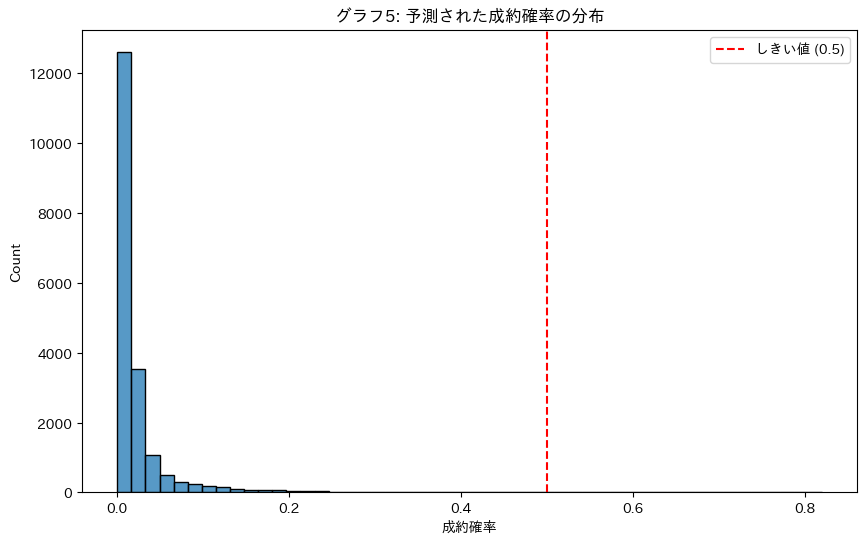

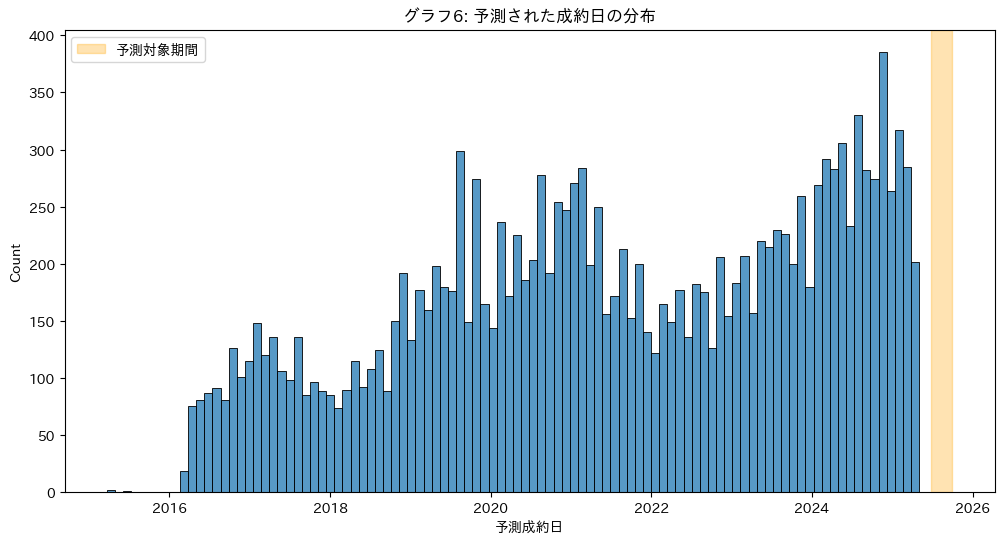

In [36]:
# --- ★★★ 5. 予測結果の分析（デバッグ用）★★★ ---
print("\n--- 5. 予測結果の分析（デバッグ用） ---")
# フィルターをかける前の予測結果を確認します

# 5-1. 予測結果の統計量を表示
print("\n▼ 予測結果（フィルター前）のサマリー:")
print(df_predict[['seiyaku_probability', 'predicted_seiyaku_date']].describe(percentiles=[.5, .75, .9, .95, .99]))

# 5-2. 成約確率が高いトップ10案件を表示
print("\n▼ 成約確率が高いトップ10案件:")
print(df_predict.sort_values('seiyaku_probability', ascending=False).head(10)[['honkosho_id', 'kigyo_name', 'seiyaku_probability', 'predicted_seiyaku_date']])

# 5-3. 成約確率の分布を可視化
plt.figure(figsize=(10, 6))
sns.histplot(df_predict['seiyaku_probability'], bins=50, kde=False)
plt.title('グラフ5: 予測された成約確率の分布')
plt.xlabel('成約確率')
plt.axvline(PROBABILITY_THRESHOLD, color='red', linestyle='--', label=f'しきい値 ({PROBABILITY_THRESHOLD})')
plt.legend()
plt.show()

# 5-4. 予測成約日の分布を可視化
plt.figure(figsize=(12, 6))
sns.histplot(df_predict['predicted_seiyaku_date'], bins=100, kde=False)
plt.title('グラフ6: 予測された成約日の分布')
plt.xlabel('予測成約日')
# 予測対象期間をハイライト
plt.axvspan(PREDICTION_START_DATE, PREDICTION_END_DATE, color='orange', alpha=0.3, label='予測対象期間')
plt.legend()
plt.show()
# --- ★★★ 分析セクションここまで ★★★ ---

In [37]:
# --- 6. 最終予測結果の集計 ---
print("\n--- 6. 最終予測結果の集計 ---")
final_prediction_df = df_predict[
    (df_predict['seiyaku_probability'] >= PROBABILITY_THRESHOLD) &
    (df_predict['predicted_seiyaku_date'] >= PREDICTION_START_DATE) &
    (df_predict['predicted_seiyaku_date'] <= PREDICTION_END_DATE)
].copy()

predicted_count = len(final_prediction_df)
final_prediction_df['seiko_hoshu'] = final_prediction_df['seiko_hoshu'].fillna(
    final_prediction_df['kijun_nenshu'] * final_prediction_df['houshuuritsu']
)
predicted_revenue = final_prediction_df['seiko_hoshu'].sum()


print("\n==================================================")
print(f"【業績予測結果】 ({PREDICTION_START_DATE.date()} ~ {PREDICTION_END_DATE.date()})")
print("==================================================")
print(f"予測成約件数: {predicted_count} 件")
print(f"予測売上金額: {predicted_revenue:,.0f} 円")
print("==================================================")

# 予測された案件の一覧を表示
print("\n▼ 予測期間内に成約が見込まれる案件リスト:")
display_columns = [
    'honkosho_id',
    'kigyo_name',
    'seiyaku_probability',
    'predicted_seiyaku_date',
    'seiko_hoshu'
]
print(final_prediction_df[display_columns].sort_values('predicted_seiyaku_date').reset_index(drop=True))



--- 6. 最終予測結果の集計 ---

【業績予測結果】 (2025-06-26 ~ 2025-09-30)
予測成約件数: 0 件
予測売上金額: 0 円

▼ 予測期間内に成約が見込まれる案件リスト:
Empty DataFrame
Columns: [honkosho_id, kigyo_name, seiyaku_probability, predicted_seiyaku_date, seiko_hoshu]
Index: []


In [38]:
df

,honkosho_id,anken_id,kohosha_id,linked_shokikosho_id,tsr_code,kigyo_name,annual_income,layer,initial_contact_date,shoki_setteibi,...,kijun_nenshu,houshuuritsu,seiko_hoshu,sai_flg,本設定Q,企担レイヤ,seiyaku_flag,first_yomi_numeric,yomi_final_numeric,yomi_change
1,1,1,663,-1,410147966,（株）ミールケア,NaN,,,NaT,...,10288954.0,55.0,5658925.0,2,None,None,1,0.0,NaN,0.0
2,2,2,165,-1,292368810,（株）大治,NaN,,,NaT,...,NaN,NaN,NaN,2,None,None,0,1.0,1.0,0.0
3,3,3,664,-1,422112860,ネクストエナジー・アンド・リソース（株）,NaN,,,NaT,...,NaN,NaN,NaN,2,None,None,0,0.0,0.0,0.0
4,4,4,455,1284,400652951,（株）メニコン,7200.0,,2016/02/24,2016-02-24,...,NaN,NaN,NaN,2,None,None,1,2.0,NaN,0.0
5,5,5,665,-1,422112860,ネクストエナジー・アンド・リソース（株）,NaN,,,NaT,...,NaN,NaN,NaN,2,None,None,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23911,25206,24055,65077,82049,290095751,セメダイン（株）,850.0,それ以外,2025/04/24,2025-07-29,...,NaN,NaN,NaN,2,28-4Q,メンバー,0,NaN,NaN,0.0
23912,25207,24056,65062,78190,018018645,飛鳥特装（株）,1500.0,本体役員クラス,2025/04/25,2025-04-24,...,NaN,NaN,NaN,2,28-4Q,メンバー,0,NaN,NaN,0.0
23913,25208,24057,66270,80512,290412730,（株）ＭＭコーポレーション,1200.0,課長クラス,2025/07/01,2025-06-19,...,NaN,NaN,NaN,1,28-4Q,メンバー,0,NaN,NaN,0.0
23914,25209,24058,57706,81723,292784414,（株）サーフビバレッジ,900.0,それ以外,2024/09/20,2025-07-22,...,NaN,NaN,NaN,2,28-4Q,メンバー,0,NaN,NaN,0.0
